<a href="https://colab.research.google.com/github/Dineshok/retail-sales-prediction/blob/main/retail_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd

# Load the sales history data
df = pd.read_csv('/content/sales_history.csv')

# Convert the Date column to datetime (fixing the capitalization error)
df['Date'] = pd.to_datetime(df['Date'])



df['day_of_week'] = df['Date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df['month'] = df['Date'].dt.month

df["day_of_month"] = df["Date"].dt.day

df['month_of_year'] = df["Date"].dt.month

df['year'] = df["Date"].dt.year

df = df.drop(columns=["Date"])

test_df = df.tail(5000)

display(df)

,Store_ID,SKU_ID,Units_Sold,Price,day_of_week,is_weekend,month,day_of_month,month_of_year,year
0,S001,SKU_101,25,1999,0,0,2,26,2,2024
1,S001,SKU_102,5,1499,0,0,2,26,2,2024
2,S001,SKU_103,3,2499,0,0,2,26,2,2024
3,S001,SKU_104,2,2499,0,0,2,26,2,2024
4,S001,SKU_105,33,999,0,0,2,26,2,2024
...,...,...,...,...,...,...,...,...,...,...
21925,S003,SKU_106,8,2499,2,0,2,25,2,2026
21926,S003,SKU_107,4,2499,2,0,2,25,2,2026
21927,S003,SKU_108,3,1999,2,0,2,25,2,2026
21928,S003,SKU_109,3,2999,2,0,2,25,2,2026


In [56]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

non_categorical_columns = df.select_dtypes(exclude=['object', 'category']).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNon-Categorical Columns:")
print(non_categorical_columns)

Categorical Columns:
['Store_ID', 'SKU_ID']

Non-Categorical Columns:
['Units_Sold', 'Price', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'month_of_year', 'year']


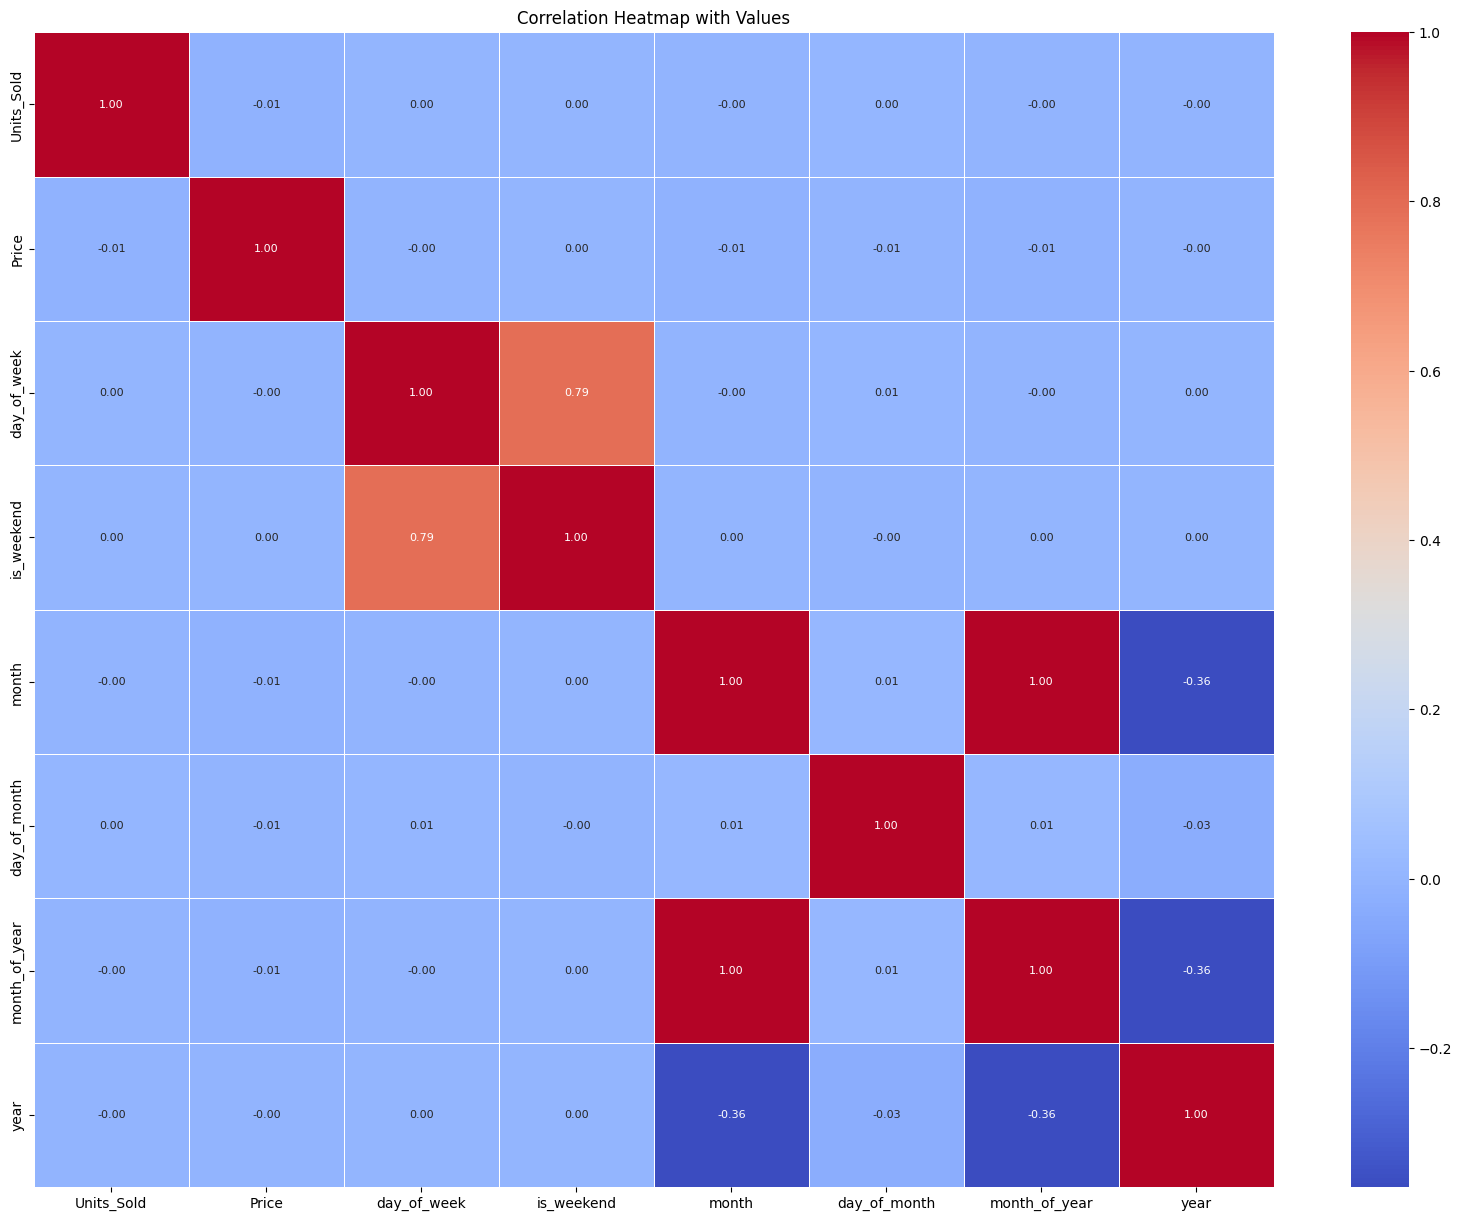

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical columns
corr_matrix = df[non_categorical_columns].corr()

# Set up the matplotlib figure
# Increased figure size slightly to accommodate text
plt.figure(figsize=(20, 15))

# Draw the heatmap with annotation (values) inside cells
# fmt='.2f' rounds the values to two decimal places
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 8})

plt.title('Correlation Heatmap with Values')
plt.show()


/tmp/ipykernel_287/3896797669.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
/tmp/ipykernel_287/3896797669.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)


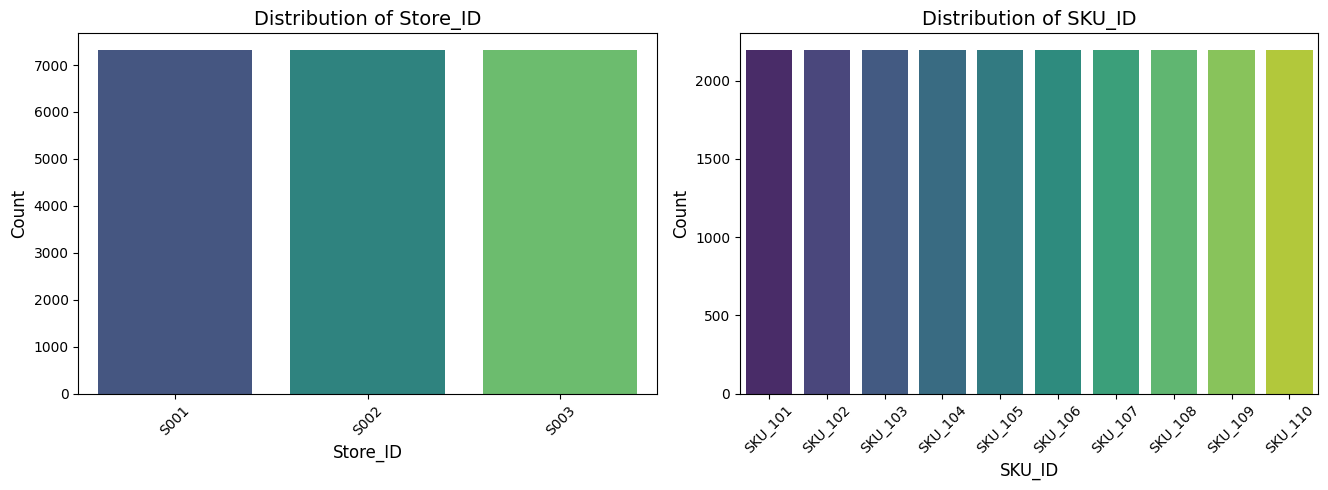

In [57]:
import math

# Define the number of columns for the subplot grid
n_cols = 3
n_rows = math.ceil(len(categorical_columns) / n_cols)

# Create a large figure to hold all count plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [69]:
import numpy as np

def mse(y, yPredicted):
  return np.mean((y - yPredicted)**2)

class LinearRegression:
    def __init__(self, numOfFeatures):
        self.W = np.zeros(numOfFeatures)

    def predict(self, X):
        assert X.shape[-1] == self.W.shape[0]
        return X @ self.W



    def nextGradient(self, X, y, learningRate):
        n = len(X)
        grad = (2/n) * X.T @ (self.predict(X) - y)
        self.W -= learningRate * grad

    def theModel(self, X, y, numOfIterations=10, learningRate=0.01):
        lossHistory = []
        for i in range(numOfIterations):
            yPredicted = self.predict(X)
            MSE = mse(y, yPredicted)
            lossHistory.append(MSE)
            self.nextGradient(X, y, learningRate)
        return lossHistory


In [70]:
import numpy as np


# 1. Fill NA values with the mean for numerical columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# 2. One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True).astype(float)

# 3. Standardize the non-categorical columns
non_categorical_data = df_encoded[non_categorical_columns].values

mean_non_cat = np.mean(non_categorical_data, axis=0)
std_non_cat = np.std(non_categorical_data, axis=0)

non_categorical_data_standardized = (non_categorical_data - mean_non_cat) / std_non_cat

# 4. Combine standardized non-categorical data with one-hot encoded categorical data
# Remove the original non-categorical columns from the encoded dataframe
df_encoded = df_encoded.drop(columns=non_categorical_columns)

# Add standardized non-categorical data back to the dataframe
df_encoded[non_categorical_columns] = non_categorical_data_standardized

# 5. Shuffle the dataset
df_encoded = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Split the data manually into training (80%) and testing (20%)
train_size = int(0.8 * len(df_encoded))

X_train = df_encoded.drop('Units_Sold', axis=1).iloc[:train_size].values
y_train = df_encoded['Units_Sold'].iloc[:train_size].values

X_test = df_encoded.drop('Units_Sold', axis=1).iloc[train_size:].values
y_test = df_encoded['Units_Sold'].iloc[train_size:].values

# 7. Add a bias term (intercept) to X
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

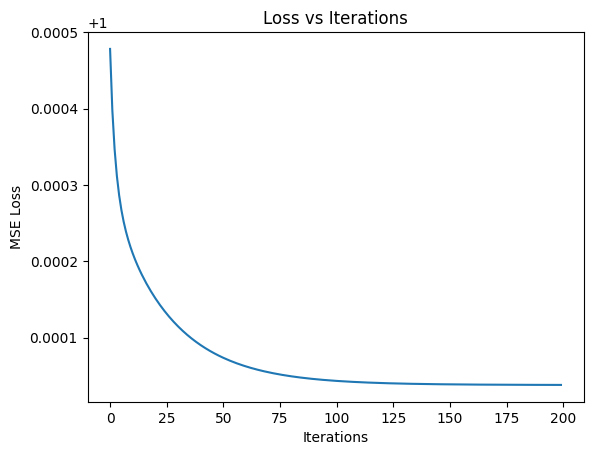

1.0000378807695083
0.9990151831578817


In [71]:
multiModel = LinearRegression(numOfFeatures = X_train.shape[1])

lossHistory = multiModel.theModel(X_train, y_train,
                             numOfIterations=200,
                             learningRate=0.1)

import matplotlib.pyplot as plt

plt.plot(lossHistory)
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.title("Loss vs Iterations")
plt.show()

print(mse(y_train, multiModel.predict(X_train)))



print(mse(y_test, multiModel.predict(X_test)))

In [72]:
import numpy as np


# 1. Fill NA values with the mean for numerical columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# 2. One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True).astype(float)

# 3. Standardize the non-categorical columns
non_categorical_data = df_encoded[non_categorical_columns].values

mean_non_cat = np.mean(non_categorical_data, axis=0)
std_non_cat = np.std(non_categorical_data, axis=0)

non_categorical_data_standardized = (non_categorical_data - mean_non_cat) / std_non_cat

# 4. Combine standardized non-categorical data with one-hot encoded categorical data
# Remove the original non-categorical columns from the encoded dataframe
df_encoded = df_encoded.drop(columns=non_categorical_columns)

# Add standardized non-categorical data back to the dataframe
df_encoded[non_categorical_columns] = non_categorical_data_standardized

# 5. Shuffle the dataset
df_encoded = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

In [73]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

# Full dataset
X = df_encoded.drop('Units_Sold', axis=1).values
y = df_encoded['Units_Sold'].values

# Add bias
X = np.c_[np.ones(X.shape[0]), X]

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

mse_scores = []

for train_index, test_index in kf.split(X):

    # Split data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Create a fresh model for each fold
    multiModel = LinearRegression(numOfFeatures=X.shape[1])

    # Train model
    lossHistory = multiModel.theModel(
        X_train, y_train,
        numOfIterations=200,
        learningRate=0.01
    )

    # Predict
    y_pred = multiModel.predict(X_test)

    # Evaluate
    mse_value = mse(y_test, y_pred)
    mse_scores.append(mse_value)

print("MSE for each fold:", mse_scores)
print("Average MSE:", np.mean(mse_scores))

print(multiModel.W)



MSE for each fold: [np.float64(1.0342247827149187), np.float64(1.004072046717444), np.float64(1.0036143315428543), np.float64(0.9957361025736039), np.float64(0.9665907042034161)]
Average MSE: 1.0008475935504475
[-0.00037392  0.00675793  0.002642    0.007114    0.00629397  0.00322782
  0.00145987 -0.00472134  0.00912106 -0.00249482 -0.00314582 -0.01407891
 -0.00666728 -0.00275205  0.0041602  -0.00219336  0.0044673  -0.00219336
 -0.01078615]


In [74]:
import numpy as np


# 1. Fill NA values with the mean for numerical columns
test_df.fillna(test_df.mean(numeric_only=True), inplace=True)

# 2. One-hot encode categorical columns
df_encoded = pd.get_dummies(test_df, columns=categorical_columns, drop_first=True).astype(float)

# 3. Standardize the non-categorical columns
non_categorical_data = df_encoded[non_categorical_columns].values

mean_non_cat = np.mean(non_categorical_data, axis=0)
std_non_cat = np.std(non_categorical_data, axis=0)

non_categorical_data_standardized = (non_categorical_data - mean_non_cat) / std_non_cat

# 4. Combine standardized non-categorical data with one-hot encoded categorical data
# Remove the original non-categorical columns from the encoded dataframe
df_encoded = df_encoded.drop(columns=non_categorical_columns)

# Add standardized non-categorical data back to the dataframe
df_encoded[non_categorical_columns] = non_categorical_data_standardized

# 5. Shuffle the dataset
df_encoded = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

/tmp/ipykernel_287/2276180186.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(test_df.mean(numeric_only=True), inplace=True)


In [77]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

# Full dataset
X = df_encoded.drop('Units_Sold', axis=1).values
y = df_encoded['Units_Sold'].values

# Add bias
X = np.c_[np.ones(X.shape[0]), X]

sample_X = X[-1]   # last row
sample_y = y[-1]   # actual value

sample_X = sample_X.reshape(1, -1)

prediction = multiModel.predict(sample_X)

print("Predicted Units Sold:", prediction[0])
print("Actual Units Sold:", sample_y)



Predicted Units Sold: -0.003370347034163627
Actual Units Sold: 0.3970242568716336
